# Supply Chain Concentration Risk — Critical Minerals

This notebook quantifies **supply chain concentration risk** for critical minerals using the
[Herfindahl-Hirschman Index (HHI)](https://en.wikipedia.org/wiki/Herfindahl%E2%80%93Hirschman_index).
A higher HHI signals that production is dominated by fewer countries, which increases
geopolitical and supply-disruption risk.

**HHI thresholds used in this analysis**
| Range | Classification |
|---|---|
| < 1 500 | Low concentration (competitive market) |
| 1 500 – 2 500 | Moderate concentration |
| > 2 500 | High concentration (oligopolistic) |

Data source: British Geological Survey (BGS) Critical Minerals Production dataset.

## 1. Environment Setup

Install required packages and import standard libraries.

In [5]:

from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_DIR = Path("../data/bgs_data")
CSV_PATH = DATA_DIR / "bgs_critical_minerals_production.csv"

# ── Plot defaults ─────────────────────────────────────────────────────────────
TEMPLATE     = "plotly_white"
HHI_MODERATE = 1500
HHI_HIGH     = 2500

print(f"Data file: {CSV_PATH}")
print(f"Exists   : {CSV_PATH.exists()}")

Data file: ../data/bgs_data/bgs_critical_minerals_production.csv
Exists   : True


## 2. Load and Clean Data

Read the CSV, keep only production records, and coerce numeric columns.
Rows with missing `quantity` or `year` are dropped.

In [6]:
raw = pd.read_csv(CSV_PATH, low_memory=False)
print(f"Raw rows : {len(raw):,}")
print(f"Columns  : {list(raw.columns)}")

# Keep production records only
df = raw.loc[raw["statistic_type"] == "Production"].copy()
print(f"\nAfter filtering to Production: {len(df):,} rows")

# Coerce numerics
df["year"]     = pd.to_numeric(df["year"],     errors="coerce")
df["quantity"] = pd.to_numeric(df["quantity"], errors="coerce")

# Drop rows with no usable quantity or year
df = df.dropna(subset=["year", "quantity"])
df["year"] = df["year"].astype(int)
print(f"After dropping NaN year/qty   : {len(df):,} rows")

# Normalise commodity names to title case for display
df["commodity"] = df["commodity"].str.strip().str.title()

print(f"\nYear range : {df['year'].min()} – {df['year'].max()}")
print(f"Commodities: {df['commodity'].nunique()}")
print(f"Countries  : {df['country'].nunique()}")

df[["commodity", "country", "year", "quantity", "units"]].describe(include="all").T

Raw rows : 59,718
Columns  : ['commodity', 'sub_commodity', 'statistic_type', 'country', 'country_iso2', 'country_iso3', 'year', 'quantity', 'units', 'yearbook_table', 'erml_commodity', 'erml_group', 'table_notes', 'figure_notes']

After filtering to Production: 59,718 rows
After dropping NaN year/qty   : 59,472 rows

Year range : 1970 – 2023
Commodities: 44
Countries  : 163


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
commodity,59472,44,"Gold, Mine",4307,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,59472,163,China,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,59472.0,NaN,NaN,NaN,1997.788169,15.601037,1970.0,1984.0,1998.0,2012.0,2023.0
quantity,59472.0,NaN,NaN,NaN,1942739.115702,24435863.19843,0.0,1625.0,22500.0,182000.0,1514240000.0
units,59472,5,tonnes (metric),33671,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Compute Herfindahl-Hirschman Index (HHI)

For each (commodity, year) group we:
1. Sum each country's production quantity.
2. Express each country's share as a **percentage** of the group total.
3. HHI = Σ (share_i)² across all countries *i*.

The maximum possible HHI is 10 000 (single-country monopoly); the minimum approaches 0 as the
number of equal-share countries grows.

In [7]:
def compute_hhi(group: pd.DataFrame) -> float:
    """Return HHI (0-10 000) for a commodity-year slice."""
    total = group["quantity"].sum()
    if total <= 0:
        return float("nan")
    shares = (group["quantity"] / total) * 100      # percentage shares
    return float((shares ** 2).sum())               # sum of squared shares


# Country-level aggregation first (a commodity can have multiple sub_commodities)
country_year = (
    df.groupby(["commodity", "year", "country"], as_index=False)["quantity"]
    .sum()
)

# HHI per commodity per year
hhi_series = (
    country_year
    .groupby(["commodity", "year"])
    .apply(compute_hhi, include_groups=False)
    .reset_index(name="hhi")
)

hhi_series = hhi_series.dropna(subset=["hhi"])
print(f"HHI records: {len(hhi_series):,}")
print(hhi_series.sort_values("hhi", ascending=False).head(10).to_string(index=False))

HHI records: 2,196
          commodity  year          hhi
   Indium, Refinery  2005 10000.000000
Rare Earth Minerals  2012 10000.000000
   Gallium, Primary  2007 10000.000000
Rare Earth Minerals  2008  9828.482756
Rare Earth Minerals  2005  9774.211597
Rare Earth Minerals  2006  9721.670605
Rare Earth Minerals  2007  9693.528608
  Rare Earth Oxides  2009  9680.258991
  Rare Earth Oxides  2010  9653.293690
  Rare Earth Oxides  2005  9520.579171


## 4. Latest-Year HHI — Horizontal Bar Chart

Using the most recent year available for each commodity, we rank all commodities by their HHI.
Vertical reference lines at **1 500** (moderate) and **2 500** (high) help interpret the bars.

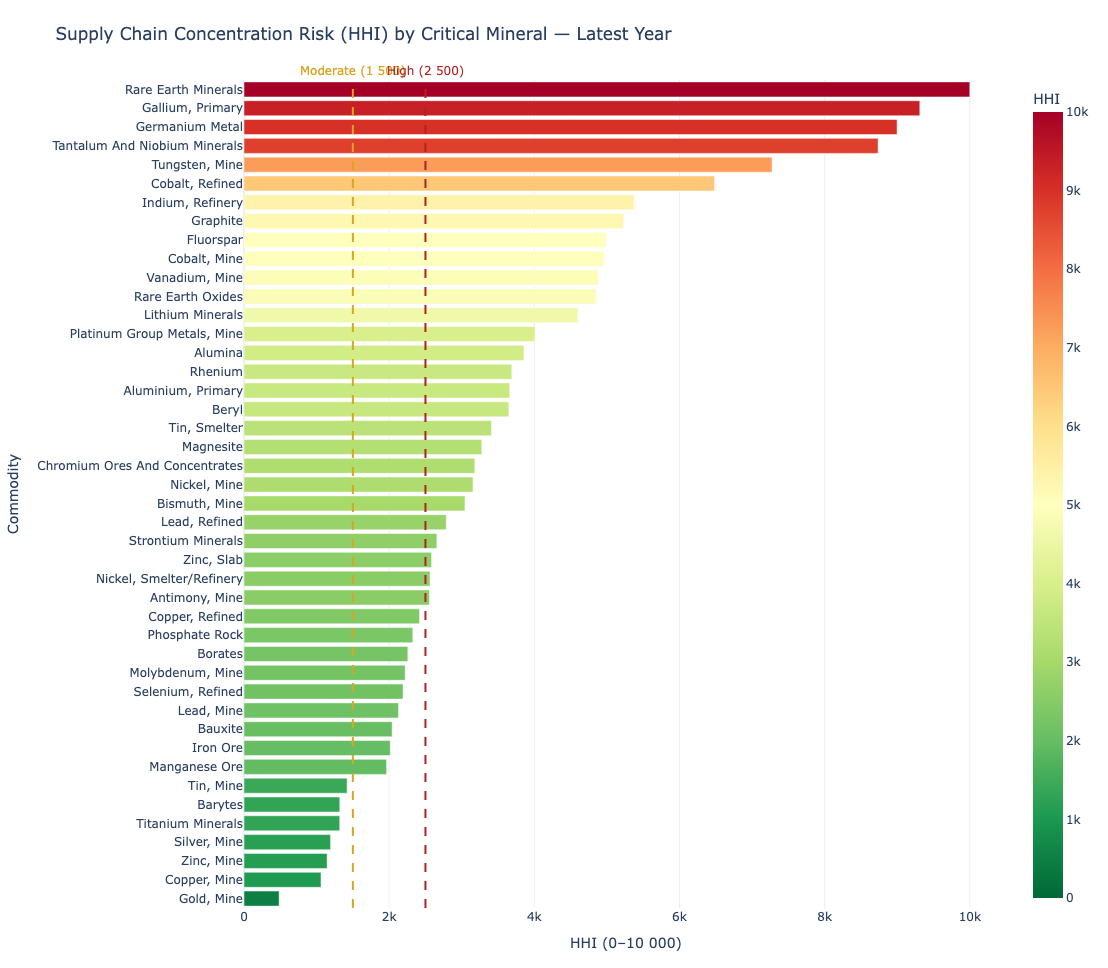

In [8]:
# Most recent year per commodity
latest_year_per_commodity = hhi_series.groupby("commodity")["year"].max().reset_index()
hhi_latest = hhi_series.merge(latest_year_per_commodity, on=["commodity", "year"])
hhi_latest = hhi_latest.sort_values("hhi", ascending=True).reset_index(drop=True)

fig_bar = px.bar(
    hhi_latest,
    x="hhi",
    y="commodity",
    orientation="h",
    color="hhi",
    color_continuous_scale="RdYlGn_r",
    range_color=[0, 10000],
    title="Supply Chain Concentration Risk (HHI) by Critical Mineral — Latest Year",
    labels={"hhi": "HHI (0–10 000)", "commodity": "Commodity"},
    template=TEMPLATE,
    height=max(500, len(hhi_latest) * 22),
)

# Reference lines
for x_val, label, colour in [
    (HHI_MODERATE, "Moderate (1 500)", "goldenrod"),
    (HHI_HIGH,     "High (2 500)",     "firebrick"),
]:
    fig_bar.add_vline(
        x=x_val,
        line_dash="dash",
        line_color=colour,
        annotation_text=label,
        annotation_position="top",
        annotation_font_color=colour,
    )

fig_bar.update_coloraxes(showscale=True, colorbar_title="HHI")
fig_bar.update_layout(margin=dict(l=200, r=60, t=80, b=60))
fig_bar.show()

## 5. HHI Over Time — Top 10 Most Concentrated Minerals

Tracking HHI through time reveals whether concentration is worsening (rising HHI) or
improving (diversifying supply base).  We focus on the 10 commodities with the **highest
latest-year HHI**.

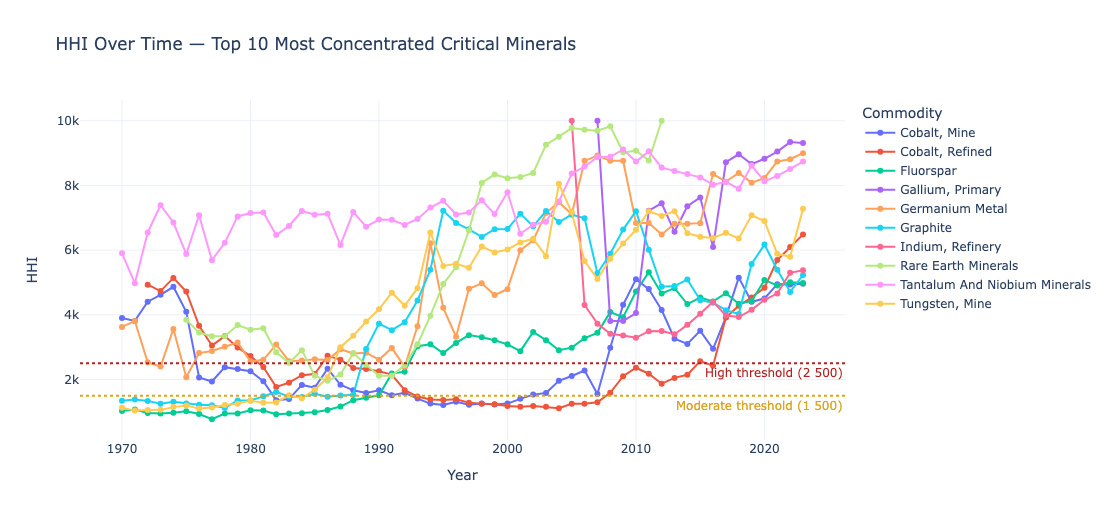

In [9]:
top10_commodities = (
    hhi_latest.sort_values("hhi", ascending=False).head(10)["commodity"].tolist()
)

hhi_top10 = hhi_series[hhi_series["commodity"].isin(top10_commodities)].copy()

fig_line = px.line(
    hhi_top10,
    x="year",
    y="hhi",
    color="commodity",
    markers=True,
    title="HHI Over Time — Top 10 Most Concentrated Critical Minerals",
    labels={"hhi": "HHI", "year": "Year", "commodity": "Commodity"},
    template=TEMPLATE,
    height=520,
)

# Reference bands
for y_val, label, colour in [
    (HHI_MODERATE, "Moderate threshold (1 500)", "goldenrod"),
    (HHI_HIGH,     "High threshold (2 500)",     "firebrick"),
]:
    fig_line.add_hline(
        y=y_val,
        line_dash="dot",
        line_color=colour,
        annotation_text=label,
        annotation_position="bottom right",
        annotation_font_color=colour,
    )

fig_line.update_layout(
    legend=dict(orientation="v", x=1.02, y=1),
    margin=dict(r=200),
)
fig_line.show()

## 6. Top Producer Shares — Stacked Horizontal Bars

For the **6 most concentrated minerals** (highest latest-year HHI) we show which countries
hold the top-5 production shares.  An "Other" slice captures the remainder.
Each row in this chart is a single commodity — a very wide bar indicates near-monopolistic
supply by the leading producer.

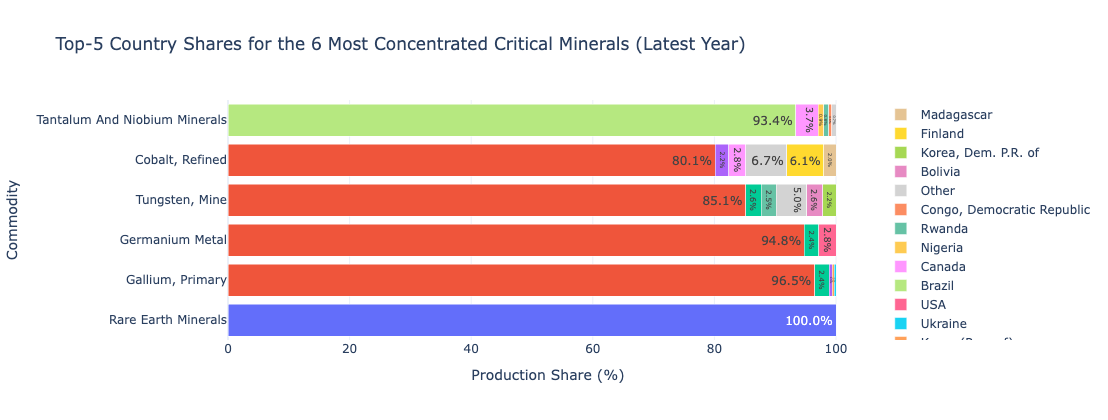

In [10]:
top6_commodities = (
    hhi_latest.sort_values("hhi", ascending=False).head(6)["commodity"].tolist()
)

# For each of the top-6 use the same latest year as hhi_latest
latest_years = dict(zip(hhi_latest["commodity"], hhi_latest["year"]))

rows_list = []
for comm in top6_commodities:
    yr = latest_years[comm]
    subset = country_year[
        (country_year["commodity"] == comm) & (country_year["year"] == yr)
    ].copy()
    total = subset["quantity"].sum()
    subset["share"] = subset["quantity"] / total * 100
    subset = subset.sort_values("share", ascending=False)
    top5   = subset.head(5)
    other  = pd.DataFrame([{
        "commodity": comm, "year": yr,
        "country": "Other", "quantity": subset.iloc[5:]["quantity"].sum(),
        "share": subset.iloc[5:]["share"].sum(),
    }]) if len(subset) > 5 else pd.DataFrame()
    rows_list.append(pd.concat([top5[["commodity", "country", "share"]], 
                                other[["commodity", "country", "share"]]
                                if not other.empty else pd.DataFrame()],
                               ignore_index=True))

share_df = pd.concat(rows_list, ignore_index=True)
share_df["country_label"] = share_df["country"] + "  " + share_df["share"].map("{:.1f}%".format)

# Assign a consistent colour palette to the most common countries
all_countries = share_df["country"].unique().tolist()
colour_seq = px.colors.qualitative.Plotly + px.colors.qualitative.Set2
country_colour = {
    c: colour_seq[i % len(colour_seq)] for i, c in enumerate(all_countries)
}
country_colour["Other"] = "#d3d3d3"

fig_stack = go.Figure()
for country in share_df["country"].unique():
    cdf = share_df[share_df["country"] == country]
    fig_stack.add_trace(go.Bar(
        name=country,
        y=cdf["commodity"],
        x=cdf["share"],
        orientation="h",
        text=cdf["share"].map("{:.1f}%".format),
        textposition="inside",
        marker_color=country_colour[country],
        hovertemplate="%{y}<br>%{fullData.name}: %{x:.1f}%<extra></extra>",
    ))

fig_stack.update_layout(
    barmode="stack",
    title="Top-5 Country Shares for the 6 Most Concentrated Critical Minerals (Latest Year)",
    xaxis_title="Production Share (%)",
    yaxis_title="Commodity",
    template=TEMPLATE,
    height=420,
    legend=dict(orientation="v", x=1.02, y=1),
    margin=dict(r=220, l=180),
)
fig_stack.show()

## 7. Risk Summary Table

A concise tabular summary showing each commodity's latest HHI, its dominant producer, that
producer's share, and an overall risk classification.  The background gradient makes high-risk
rows immediately visible.

In [12]:
def risk_level(hhi: float) -> str:
    if hhi >= HHI_HIGH:
        return "HIGH"
    elif hhi >= HHI_MODERATE:
        return "MODERATE"
    return "LOW"


summary_rows = []
for _, row in hhi_latest.iterrows():
    comm = row["commodity"]
    yr   = row["year"]
    hhi  = row["hhi"]
    subset = country_year[
        (country_year["commodity"] == comm) & (country_year["year"] == yr)
    ].copy()
    total = subset["quantity"].sum()
    if total <= 0:
        continue
    subset["share"] = subset["quantity"] / total * 100
    top = subset.sort_values("share", ascending=False).iloc[0]
    summary_rows.append({
        "Commodity":              comm,
        "Latest Year":            yr,
        "HHI":                    round(hhi, 0),
        "Top Producer":           top["country"],
        "Top Producer Share (%)": round(top["share"], 1),
        "Risk Level":             risk_level(hhi),
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("HHI", ascending=False)
    .reset_index(drop=True)
)

risk_counts = summary_df["Risk Level"].value_counts()
print("Risk level distribution:")
print(risk_counts.to_string())
print()

def colour_risk(val: str) -> str:
    mapping = {"HIGH": "background-color: #ff4c4c; color: white; font-weight: bold",
               "MODERATE": "background-color: #ffd966; color: black; font-weight: bold",
               "LOW": "background-color: #93c47d; color: black"}
    return mapping.get(val, "")

(
    summary_df.style
    
    .map(colour_risk, subset=["Risk Level"])
    .format({"HHI": "{:.0f}", "Top Producer Share (%)": "{:.1f}"})
    .set_caption("Supply Chain Concentration Risk Summary — Critical Minerals")
    .set_table_styles([{"selector": "caption",
                        "props": [("font-size", "14px"),
                                  ("font-weight", "bold"),
                                  ("caption-side", "top")]}])
)

Risk level distribution:
Risk Level
HIGH        28
MODERATE     9
LOW          7



,Commodity,Latest Year,HHI,Top Producer,Top Producer Share (%),Risk Level
0,Rare Earth Minerals,2012,10000,Malaysia,100.0,HIGH
1,"Gallium, Primary",2023,9311,China,96.5,HIGH
2,Germanium Metal,2023,8998,China,94.8,HIGH
3,Tantalum And Niobium Minerals,2023,8737,Brazil,93.4,HIGH
4,"Tungsten, Mine",2023,7276,China,85.1,HIGH
5,"Cobalt, Refined",2023,6484,China,80.1,HIGH
6,"Indium, Refinery",2023,5377,China,72.0,HIGH
7,Graphite,2023,5232,China,71.4,HIGH
8,Fluorspar,2023,4988,China,69.3,HIGH
9,"Cobalt, Mine",2023,4962,"Congo, Democratic Republic",69.3,HIGH


## 8. Key Findings

- Commodities with HHI > 2 500 represent the highest-priority supply chain risks; their
  production is effectively controlled by one or two countries.
- The time-series chart reveals whether concentration is a structural trend or a transient
  anomaly — sustained high HHI warrants greater concern than a one-year spike.
- The stacked-bar panel shows which specific countries drive concentration; allied-nation
  dominance carries different risk than adversarial-nation dominance.
- Use the risk summary table as a screening tool to prioritise deeper analysis or
  policy interventions.